# import

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


# step 1.1 - Load and Explore Dataset

In [2]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")


 **Shape & *first* 5 rows & Missing Values &  Class Distribution**

In [3]:
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"first 5 rows: {df.head()}")
print(f"column names:) {df.columns}")
print(" Missing Values")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")


Shape: (48204, 9)
Rows: 48204
Columns: 9
first 5 rows:   holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  
column names:) Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')
 Missing Values
h

In [8]:
df['holiday'].fillna('None', inplace=True)

/tmp/ipykernel_2983/1084375229.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['holiday'].fillna('None', inplace=True)


In [14]:
print(df.duplicated().sum())

0


In [13]:
df.drop_duplicates(inplace=True)

In [9]:
print(df.isnull().sum())

holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64


**Feature Engineering**

In [15]:
#Convert Date Column

df['date_time'] = pd.to_datetime(df['date_time'])

#Extract Features

df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['weekday'] = df['date_time'].dt.weekday

#Create Traffic Categories

def traffic_level(x):

    if x < 2000:
        return 'Low'

    elif x < 5000:
        return 'Medium'

    else:
        return 'High'


df['traffic_category'] = df['traffic_volume'].apply(
    traffic_level
)

In [17]:
#Check Classes
print(df['traffic_category'].value_counts())

traffic_category
Medium    21618
Low       15216
High      11353
Name: count, dtype: int64


**Traffic Category Distribution**

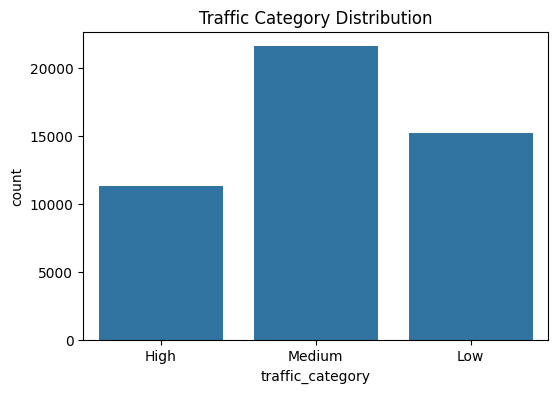

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='traffic_category',
    data=df
)

plt.title('Traffic Category Distribution')

plt.show()

**Traffic Volume Distribution**

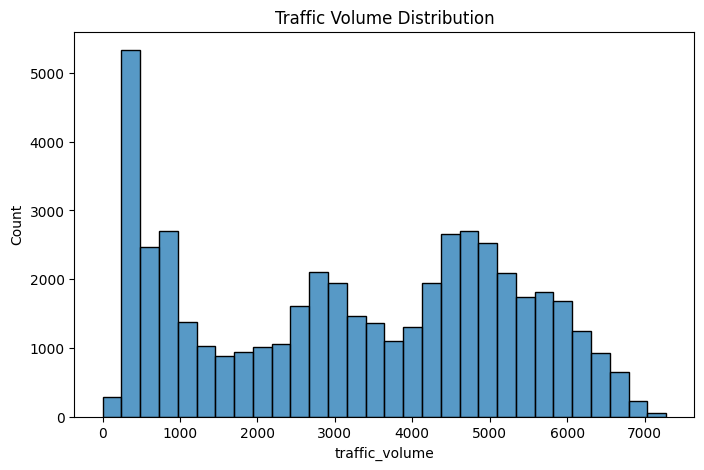

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['traffic_volume'],
    bins=30
)

plt.title('Traffic Volume Distribution')

plt.show()

**Traffic by Hour**

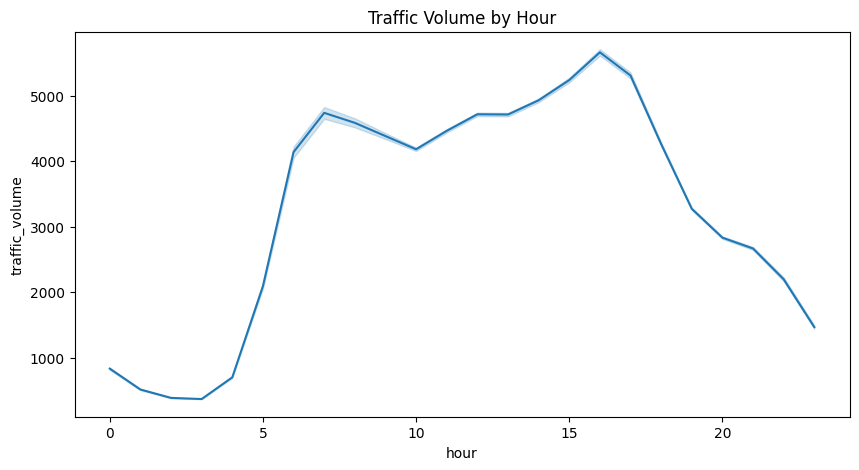

In [21]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x='hour',
    y='traffic_volume',
    data=df
)

plt.title('Traffic Volume by Hour')

plt.show()

**Correlation Heatmap**

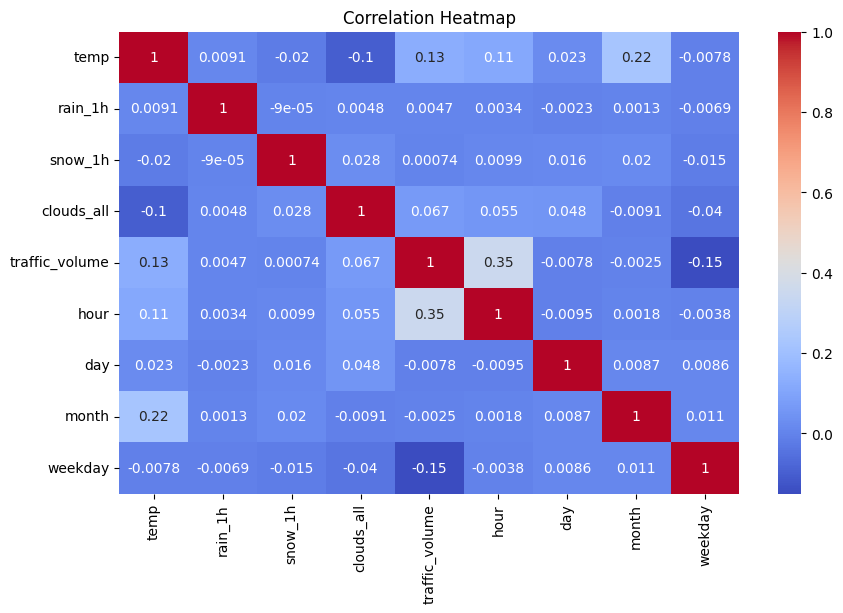

In [22]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**Encoding**

In [25]:
categorical_columns = [
    'holiday',
    'weather_main',
    'weather_description'
]

encoder = LabelEncoder()

for col in categorical_columns:

    df[col] = encoder.fit_transform(df[col])

In [26]:
#Encode Target
target_encoder = LabelEncoder()

df['traffic_category'] = target_encoder.fit_transform(
    df['traffic_category']
)

In [27]:
# Features and Target
X = df[[
    'holiday',
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'weather_main',
    'weather_description',
    'hour',
    'day',
    'month',
    'weekday'
]]

y = df['traffic_category']


# Step 1.2 — Prepare the Data


In [28]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

**Model (1) Logistic Regression**

In [29]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.40      0.11      0.17      2271
           1       0.67      0.80      0.73      3043
           2       0.64      0.79      0.71      4324

    accuracy                           0.64      9638
   macro avg       0.57      0.57      0.54      9638
weighted avg       0.59      0.64      0.59      9638



**Logistic Regression Confusion Matrix**

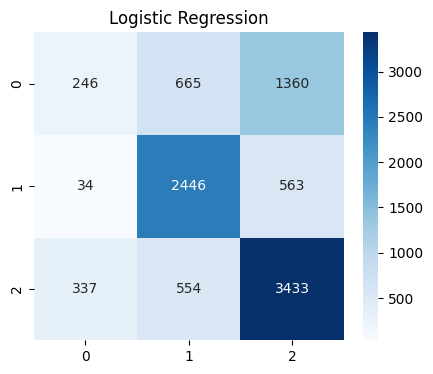

In [31]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression')

plt.show()

**Model (2) Random Forest**

In [32]:
rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [33]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.91      0.90      0.90      2271
           1       0.97      0.95      0.96      3043
           2       0.92      0.93      0.92      4324

    accuracy                           0.93      9638
   macro avg       0.93      0.93      0.93      9638
weighted avg       0.93      0.93      0.93      9638



**Random Forest Confusion Matrix**

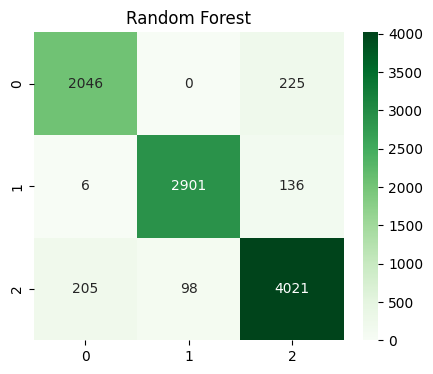

In [34]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Random Forest')

plt.show()

**Model (3) KNN**

In [35]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [36]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.64      0.67      0.66      2271
           1       0.85      0.81      0.83      3043
           2       0.75      0.76      0.75      4324

    accuracy                           0.75      9638
   macro avg       0.75      0.75      0.75      9638
weighted avg       0.76      0.75      0.75      9638



**KNN Confusion Matrix**

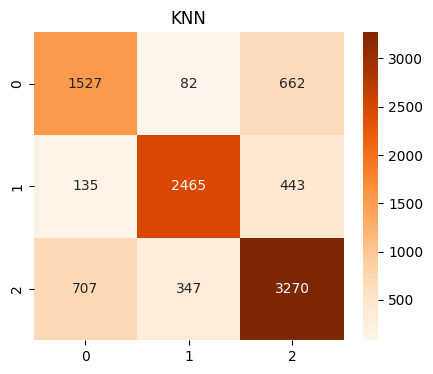

In [37]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('KNN')

plt.show()

# Step 1.3 — Train and Compare Models

In [38]:
results = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'Random Forest',

        'KNN'
    ],

    'Accuracy': [

        accuracy_score(y_test, log_pred),

        accuracy_score(y_test, rf_pred),

        accuracy_score(y_test, knn_pred)
    ],

    'Precision': [

        precision_score(
            y_test,
            log_pred,
            average='weighted'
        ),

        precision_score(
            y_test,
            rf_pred,
            average='weighted'
        ),

        precision_score(
            y_test,
            knn_pred,
            average='weighted'
        )
    ],

    'Recall': [

        recall_score(
            y_test,
            log_pred,
            average='weighted'
        ),

        recall_score(
            y_test,
            rf_pred,
            average='weighted'
        ),

        recall_score(
            y_test,
            knn_pred,
            average='weighted'
        )
    ],

    'F1-Score': [

        f1_score(
            y_test,
            log_pred,
            average='weighted'
        ),

        f1_score(
            y_test,
            rf_pred,
            average='weighted'
        ),

        f1_score(
            y_test,
            knn_pred,
            average='weighted'
        )
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.635505   0.592225  0.635505  0.588616
1        Random Forest  0.930484   0.930694  0.930484  0.930552
2                  KNN  0.753476   0.756135  0.753476  0.754559


# STEP 2: NEURAL NETWORK

In [71]:
#Convert Labels
y_train_cat = to_categorical(y_train)

y_test_cat = to_categorical(y_test)

In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [87]:
#Build Model
model = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    Dropout(0.2),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.2),

    Dense(
        3,
        activation='softmax'
    )
])

#Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [88]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    shuffle=True,

    epochs=100,

    batch_size=32,

    callbacks=[early_stop]
)

Epoch 1/100
964/964 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6830 - loss: 0.6704 - val_accuracy: 0.7606 - val_loss: 0.4857
Epoch 2/100
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7647 - loss: 0.5040 - val_accuracy: 0.8266 - val_loss: 0.4086
Epoch 3/100
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8152 - loss: 0.4404 - val_accuracy: 0.8776 - val_loss: 0.3506
Epoch 4/100
964/964 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8478 - loss: 0.3761 - val_accuracy: 0.8921 - val_loss: 0.3115
Epoch 5/100
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8647 - loss: 0.3497 - val_accuracy: 0.9000 - val_loss: 0.2963
Epoch 6/100
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8727 - loss: 0.3306 - val_accuracy: 0.8994 - val_loss: 0.2925
Epoch 7/100
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8764 - loss: 0.3198 - val_accuracy: 0.8994 - val_loss: 0.2851
Epoch 8/100
964/964 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8818 - loss: 0.3086 - val_accu

**Plot Accuracy**

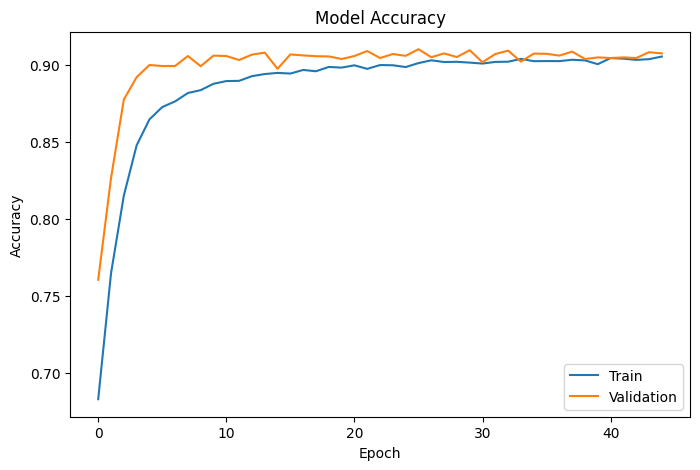

In [113]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

**Plot Loss**

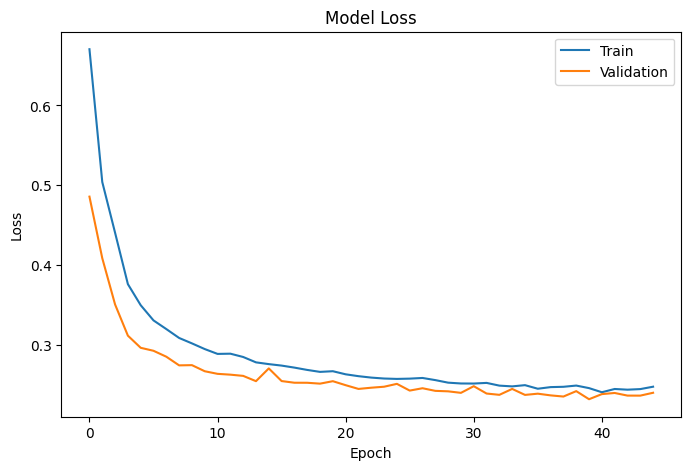

In [112]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

**Evaluate Neural Network**

In [107]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictions
y_pred_nn = model.predict(X_test)
y_pred_nn = np.argmax(y_pred_nn, axis=1)

# Metrics
precision_nn = precision_score(y_test, y_pred_nn, average='weighted')
recall_nn = recall_score(y_test, y_pred_nn, average='weighted')
f1_nn = f1_score(y_test, y_pred_nn, average='weighted')

print("Neural Network Results:")
print("Precision:", precision_nn)
print("Recall:", recall_nn)
print("F1-Score:", f1_nn)

302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Neural Network Results:
Precision: 0.9101287494664059
Recall: 0.9096285536418344
F1-Score: 0.9098096835834374


In [95]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Neural Network Accuracy:", accuracy)

302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9096 - loss: 0.2243
Neural Network Accuracy: 0.9096285700798035


**The Neural Network achieved an accuracy of approximately 91%, which indicates strong performance in classifying traffic congestion levels based on weather and temporal features.**

# **Evaluation Results of All Models**

In [111]:
final_df = results.copy()

final_df.loc[len(final_df)] = [
    "Neural Network",
    accuracy,
    precision_nn,
    recall_nn,
    f1_nn
]

print(final_df.to_string(index=False))

print("\nBest Model:",
      final_df.loc[final_df["F1-Score"].fillna(0).idxmax(), "Model"])

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.635505   0.592225 0.635505  0.588616
      Random Forest  0.930484   0.930694 0.930484  0.930552
                KNN  0.753476   0.756135 0.753476  0.754559
     Neural Network  0.909629   0.910129 0.909629  0.909810

Best Model: Random Forest


**"The Neural Network performed slightly worse than the Random Forest model, which achieved the highest F1-Score of 0.9305 compared to the network's 0.9098. This indicates that for this specific dataset, tree-based ensemble methods were more effective at establishing clear decision boundaries without the need for extensive architectural tuning. However, the Neural Network demonstrated strong generalization and stable learning curves, significantly outperforming simpler baseline models such as KNN and Logistic Regression."**